# Arbeid

## Doelen

Nu dat we de microscopische grootheden van de moleculen hebben verbonden aan de macroscopische grootheden van het gas, kunnen we de thermodynamica van het gas echt modelleren met onze simulatie. In dit werkblad gaan we kijken hoe de temperatuur en de druk veranderen onder invloed van een zuiger die het volume verandert. 

Eerst herhalen we de delen van de code die we nodig hebben:

- klasse voor het deeltje met bijbehorende functies
- variabelen en randcondities van controle volume
- functies voor een lijst deeltjes

Daarna voegen we code toe voor de dynamiek van de zuiger:

- zuiger implementeren in volume en dynamische formules
- bestuderen van temperatuur en druk als functie van volume

## Laden van eerdere code

We beginnen weer met de noodzakelijke pakketten en de constanten. Daar voegen we nu een constante aan toe: de startsnelheid van de zuiger. 


(Tekst Freek: 10 deeltjes, met bewegend wand, eerst isotherm (snelheid van deeltjes niet gewijzigd) - snelheid van deeltjes verandert wel door beweging vd wand. p(t) en p(V))

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

BOX_SIZE_0 = 10                # Hoogte en breedte startvolume
N = 40                         # Aantal deeltjes
V_0 = 1                        # Startsnelheid van deeltjes
RADIUS = 0.3                   # Straal van moleculen
DT = 0.1 * RADIUS / V_0        # Tijdstap om geen botsing te missen
V_PISTON_0 = -0.1              # Startsnelheid van zuiger 
# (negatief naar binnen gericht en aan beide zijdes deze snelheid)

De klasse voor de gasmoleculen en de functies voor hun onderlinge interactie:

In [2]:
class ParticleClass:
    def __init__(self, m, v, r, R):
        """ maakt een deeltje (constructor) """
        self.m = m                         
        self.v = np.array(v, dtype=float)  
        self.r = np.array(r, dtype=float)  
        self.R = R

    def update_position(self):
        """ verandert positie voor één tijdstap """
        self.r += self.v * DT 
            
    @property
    def momentum(self):
        return self.m * self.v
    
    @property
    def kin_energy(self):
        return 1/2 * self.m * np.dot(self.v, self.v)
    
def collide_detection(p1: ParticleClass, p2: ParticleClass) -> bool:
    """ Geeft TRUE als de deeltjes overlappen """
    return np.linalg.norm(p1.r - p2.r) < (p1.R + p2.R)


def particle_collision(p1: ParticleClass, p2: ParticleClass):
    """ past snelheden aan uitgaande van overlap """
    r1, r2 = p1.r, p2.r
    v1, v2 = p1.v, p2.v
    m1, m2 = p1.m, p2.m
    delta_r = r1 - r2
    delta_v = v1 - v2
    # Als deeltjes van elkaar weg bewegen dan geen botsing
    if np.dot(delta_r, delta_v) > 0:
        return
    distance_squared = np.dot(delta_r, delta_r) + 1e-12  # voorkom deling door 0
    # Botsing oplossen volgens elastische botsing in 2D
    v1_new = v1 - 2 * m2 / (m1 + m2) * np.dot(delta_v, delta_r) / distance_squared * delta_r
    v2_new = v2 - 2 * m1 / (m1 + m2) * np.dot(-delta_v, -delta_r) / distance_squared * (-delta_r)
    p1.v = v1_new
    p2.v = v2_new

Het volume en de randvoorwaarden zullen we moeten aanpassen aan de nieuwe situatie. Het volume zal nu niet meer altijd een vierkant zijn van `BOX_SIZE_0` bij `BOX_SIZE_0`. Laten we aannemen dat de zuiger altijd in de horizontale richting verplaatst en het volume symmetrisch houdt ten opzichte van de oorsprong. Er is dus een zuiger aan de linker wand die een tegengestelde verplaatsing heeft aan die in de rechter wand. 

We maken eerst een aantal variabelen aan die bij het volume horen:

In [3]:
box_height = BOX_SIZE_0
box_length = BOX_SIZE_0
pressure = 0.0
v_piston = V_PISTON_0

De functies die bij het volume en de randvoorwaarden horen moeten we een klein beetje aanpassen, zodat we niet langer uitgaan van de constante waarde van de lengte en hoogte. Om de variabelen `box_height` en `box_length` die we hierboven gedefinieerd hebben, later in functies te gebruiken, moeten we ze telkens oproepen met het keyword `global`. Dit is hieronder uitgewerkt. 

In [4]:
def box_collision(particle: ParticleClass):
    global box_length, box_height
    """ botsing met harde wanden """
    if abs(particle.r[0]) + particle.R > box_length / 2: 
        particle.v[0] = -particle.v[0]                                       # Omdraaien van de snelheid
        particle.r[0] = np.sign(particle.r[0]) * (box_length/2 - particle.R)  # Zet terug net binnen box                 
    if abs(particle.r[1]) + particle.R > box_height / 2: 
        particle.v[1] = -particle.v[1]     
        particle.r[1] = np.sign(particle.r[1]) * (box_height/2 - particle.R) 

En dan laden we ook alle functies die over de gehele lijst met deeltjes werken. Let op dat we ook hier de nodige variabelen met `global` moeten aanroepen.

In [5]:
def create_particles(particles):
    """ Leegmaken en opnieuw aanmaken van deeltjes  in lijst """
    global box_length, box_height
    particles.clear()
    for _ in range(N):
        vx = np.random.uniform(-V_0, V_0)
        vy = np.random.choice([-1, 1]) * np.sqrt(V_0**2 - vx**2)        
        x = np.random.uniform(-box_length/2 + RADIUS, box_length/2 - RADIUS)
        y = np.random.uniform(-box_height/2 + RADIUS, box_height/2 - RADIUS)
        particles.append(ParticleClass(m=1.0, v=[vx, vy], r=[x, y], R=RADIUS))
    
def temperature(particles) -> float:
    temp = 0.0
    for p in particles:
        temp += p.kin_energy
    temp = temp / len(particles)
    return temp
        
def handle_collisions(particles):
    """ alle onderlinge botsingen afhandelen voor deeltjes in lijst """
    ignore_list = []
    for p1 in particles:
        if p1 in ignore_list:                                   # overslaan als partner al geweest is
            continue
        for p2 in particles:
            if p1 is p2:
                continue
            if collide_detection(p1, p2):
                particle_collision(p1, p2)
                ignore_list.append(p2)                          # partner uitsluiten van de berekening

def handle_walls(particles):
    """ botsing met wanden controleren voor alle deeltjes in lijst en bepaling druk """
    global pressure, box_length, box_height     # om pressure buiten de functie te kunnen gebruiken
    total_impulse = 0.0                         # totale stoot op wanden
    for p in particles:
        momentum_old = p.momentum.copy()
        box_collision(p)
        impulse = p.momentum - momentum_old
        total_impulse += np.linalg.norm(impulse)**0.5 # stoot is altijd netjes loodrecht naar buiten
    pressure = pressure = 0.95 * pressure + 0.05 * total_impulse / ((2 * box_length + 2 * box_height) * DT) 

def take_time_step(particles):
    """ zet tijdstap voor een lijst deeltjes en verwerk alle botsingen onderling en met wanden """
    for p in particles:
        p.update_position()
    handle_walls(particles)  
    handle_collisions(particles)

## Implementeren (dubbele) zuiger



Voordat we nog meer veranderingen aan de code doorvoeren, moeten we eerst controleren of alles nog werkt.

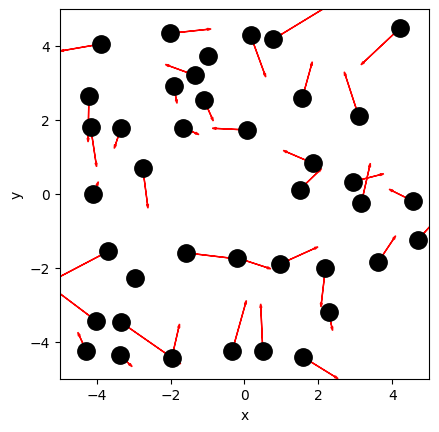

In [6]:
particles = []
create_particles(particles)
for i in range(100):
    take_time_step(particles)

plt.figure()
plt.xlabel('x')
plt.ylabel('y')
plt.gca().set_aspect('equal')
plt.xlim(-BOX_SIZE_0/2, BOX_SIZE_0/2)
plt.ylim(-BOX_SIZE_0/2, BOX_SIZE_0/2)

for p in particles:
    plt.plot(p.r[0], p.r[1], 'k.', ms=25)
    plt.arrow(p.r[0], p.r[1], p.v[0], p.v[1], 
              head_width=0.05, head_length=0.1, color='red')
plt.show()

Nu implementeren we de zuiger door het toegestane gebied voor de gasdeeltjes bij elke tijdstap te verkleinen met een stap $v_\text{piston}*dt$.

In [7]:
def take_time_step(particles):
    """ zet tijdstap voor een lijst deeltjes en verwerk alle botsingen onderling en met wanden """
    global box_length
    box_length += 2 * v_piston * DT # zowel links als rechts zuiger
    for p in particles:
        p.update_position()
    handle_walls(particles)  
    handle_collisions(particles)

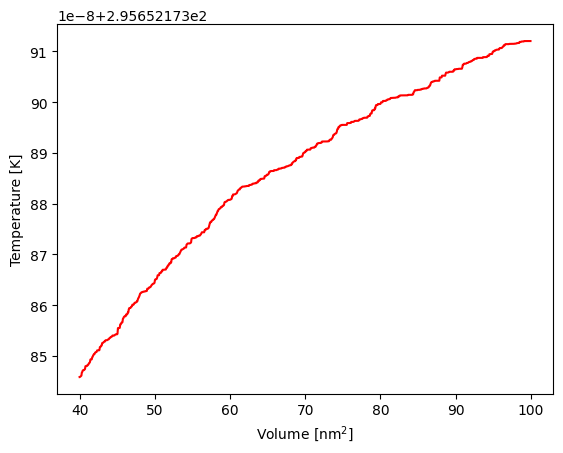

In [8]:
particles = []
volumes = np.zeros(1000, dtype=float)
temperatures = np.zeros(1000, dtype=float)
# times = np.linspace(1, 100, 100)

box_length = BOX_SIZE_0         # zetten zuiger terug
v_piston =V_PISTON_0
create_particles(particles)     # resetten deeltjes     
for i in range(1000):
    take_time_step(particles)
    volumes[i] = box_length * box_height
    temperatures[i] = temperature(particles)

plt.figure()
plt.xlabel('Volume [nm$^2$]')
plt.ylabel('Temperature [K]')

temperatures = np.asarray(temperatures) * 30 * 1.7E-27 * (1E-9 / 2.5E-12)**2 / 1.38E-23

plt.plot(volumes, temperatures, '-r')

plt.show()

Dit kan niet kloppen. Hier zien we dat de temperatuur vrijwel constant is (let op de vermenigvuldigingsfactor vermeld aan de bovenkant van de verticale as). Maar de zuiger voert arbeid uit en dat betekent dat de temperatuur moet veranderen. 

Om het model kloppend te maken moeten we kijken naar de botsing van de deeltjes met de wand. In de vorige werkbladen stonden de wanden stil en veranderde de snelheid van de deeltjes alleen van teken in de component loodrecht op de wand. Nu dat de wanden een zuiger zijn en snelheid hebben, moeten we daarvoor corrigeren.

De snelheid van de deeltjes klapt nog steeds om van teken in het referentiestelsel van de wand, maar omdat de wand beweegt ten opzichte van het volume met snelheid $v_\text{piston}$, wordt de juiste procedure:

In [9]:
def box_collision(particle: ParticleClass):
    """ botsing met harde wanden bij bewegende zuiger """
    global box_length, box_height, v_piston    
    if particle.r[0] + particle.R > box_length / 2:
        particle.v[0] = -particle.v[0] + 2*v_piston
        particle.r[0] = box_length/2 - particle.R             
    elif particle.r[0] - particle.R < -box_length / 2:
        particle.v[0] = -particle.v[0] - 2*v_piston
        particle.r[0] = -box_length/2 + particle.R              
    if abs(particle.r[1]) + particle.R > box_height / 2: 
        particle.v[1] = -particle.v[1]     
        particle.r[1] = np.sign(particle.r[1]) * (box_height/2 - particle.R) 

Nu kunnen we de simulatie opnieuw uitvoeren:

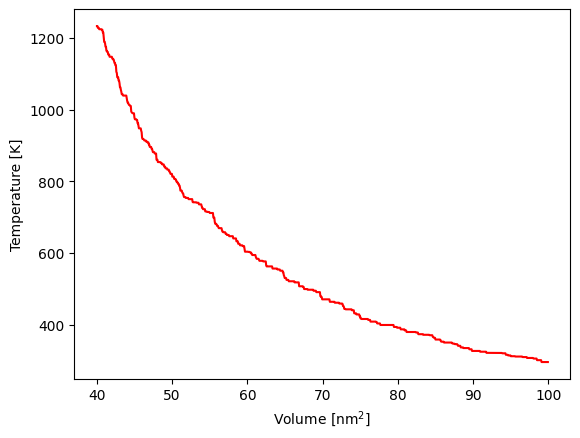

In [10]:
particles = []
volumes = np.zeros(1000, dtype=float)
temperatures = np.zeros(1000, dtype=float)
# times = np.linspace(1, 100, 100)

box_length = BOX_SIZE_0         # zetten zuiger terug
v_piston = V_PISTON_0
create_particles(particles)     # resetten deeltjes 
for i in range(1000):
    take_time_step(particles)
    volumes[i] = box_length * box_height
    temperatures[i] = temperature(particles)

plt.figure()
plt.xlabel('Volume [nm$^2$]')
plt.ylabel('Temperature [K]')

temperatures = np.asarray(temperatures) * 30 * 1.7E-27 * (1E-9 / 2.5E-12)**2 / 1.38E-23

plt.plot(volumes, temperatures, '-r')

plt.show()

Voordat we kijken of deze resultaten kloppen, eerst een opdracht:

```{exercise}
Maak een simulatie waarin niet de temperatuur, maar de druk als functie van het formule wordt geplot. Maak hier een simulatie van 1000 tijdstappen. 
```

In [11]:
# RUIMTE VOOR UITWERKING

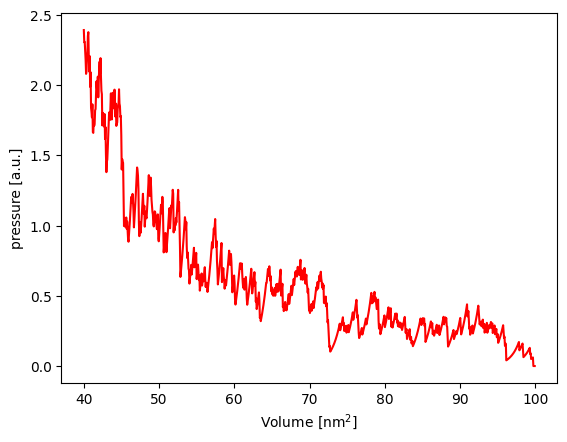

In [12]:
#VOORBEELDUITWERKING

particles = []
volumes = np.zeros(1000, dtype=float)
pressures = np.zeros(1000, dtype=float)
# times = np.linspace(1, 100, 100)

pressure = 0.0
box_length = BOX_SIZE_0         # zetten zuiger terug
v_piston = V_PISTON_0
create_particles(particles)     # resetten deeltjes 
for i in range(1000):
    take_time_step(particles)
    volumes[i] = box_length * box_height
    pressures[i] = pressure

plt.figure()
plt.xlabel('Volume [nm$^2$]')
plt.ylabel('pressure [a.u.]')

plt.plot(volumes, pressures, '-r')

plt.show()

De relatie tussen de druk en het volume is hier een machtsfunctie. 

```{exercise}
Leg uit welke factor je hier verwacht voor de machtsterm op basis van de theorie van het boek.
```

```{exercise}
Bepaal met behulp van een fit wat het resultaat van de simulatie voor de machtsterm is.
```

In [13]:
from scipy.optimize import curve_fit
# RUIMTE VOOR UITWERKING

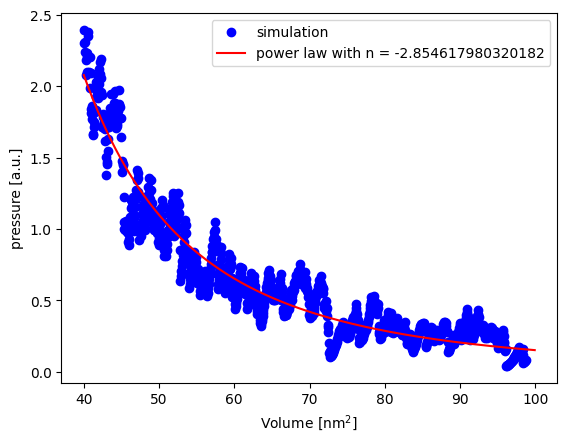

In [14]:
# VOORBEELDUITWERKING

def power_law(vol, a, n):
    return a * vol**n    

# we fitten de eerste 20 punten niet mee in verband met de integrator vd druk
popt, pocv = curve_fit(power_law, volumes[20:], pressures[20:])

x_fit = volumes
y_fit = power_law(x_fit, *popt)

plt.figure()
plt.xlabel('Volume [nm$^2$]')
plt.ylabel('pressure [a.u.]')

plt.plot(volumes[20:], pressures[20:], 'bo', label='simulation')
plt.plot(x_fit, y_fit, 'r-', label='power law with n = ' + str(popt[1]))

plt.legend()

plt.show()

Als je de simulatie een aantal keer uitvoert, zie je dat er een structureel verschil zit tussen de waarde die je verwacht en de waarde die je uit de fit krijgt. Is er dan toch ergens een fout in de code geslopen? Om dat uit te sluiten kunnen we het best een controle-experiment bedenken. 

We gaan de simulatie controleren op het voldoen aan de eerste hoofdwet van de thermodynamica. Omdat er (nog) geen warmte wordt uitgewisseld, moeten we hiervoor alleen de uitgevoerde arbeid bepalen.  

De arbeid wordt geleverd door de zuiger(s) op de gasmoleculen. Dus op het moment dat we de botsingen van de moleculen met de wand behadelen, kunnen we ook de verrichte arbeid bepalen. Volgens het boek wordt die bepaalt door:

$$
    W = \int_1^2 P dV
$$

Wat in de differentiaalvorm geschreven kan worden als:

$$
    dW = P dV
$$

Voor ons experiment, waar het volume niet geleidelijk maar in stapjes verandert, kan je dit herschrijven door:

$$ 
    \Delta W = P \Delta V \stackrel{2D}{=} P \Delta A = P v_\text{piston} h \Delta t = \frac{\Delta p}{h \Delta t} v_\text{piston} h \Delta t = v_\text{piston}\Delta p
$$

In onze code kunnen we de arbeid per tijdstap bepalen op hetzelfde moment dat we de druk bepalen. Daarvoor moeten we de code voor de functie `handle_walls` nogmaals aanpassen:

In [15]:
def handle_walls(particles):
    """ botsing met wanden controleren voor alle deeltjes in lijst en bepaling druk """
    global pressure, box_length, box_height, work     # om pressure buiten de functie te kunnen gebruiken
    total_impulse = np.zeros(2, dtype=float)    # totale stoot op wanden per richting
    for p in particles:
        momentum_old = p.momentum.copy()
        box_collision(p)
        impulse = p.momentum - momentum_old 
        total_impulse += abs(impulse) # stoot is altijd netjes loodrecht naar buiten
    pressure = 0.95 * pressure + 0.05 * sum(total_impulse) / ((2 * box_length + 2 * box_height) * DT) 
    work -= total_impulse[0] * v_piston # CHECK

Voordat we een simulatie draaien is het goed even stil te staan en na te denken. Net als bij een experiment in het lab doorlopen we bewust de onderzoekscyclus. We moeten daarvoor eerst een hypothese opstellen en daarna pas de simulatie uitvoeren. 

```{exercise}
Welke twee grootheden kan je nu tegen elkaar uitzetten om te valideren of de simulatie aan de eerste hoofdwet voldoet? En welke grafiek verwacht je dan dat daar uitkomt?
```


```{exercise}
Stel de code op om deze grafiek te produceren en vergelijk het resultaat met je hypothese.
```

In [16]:
# RUIMTE VOOR UITWERKING

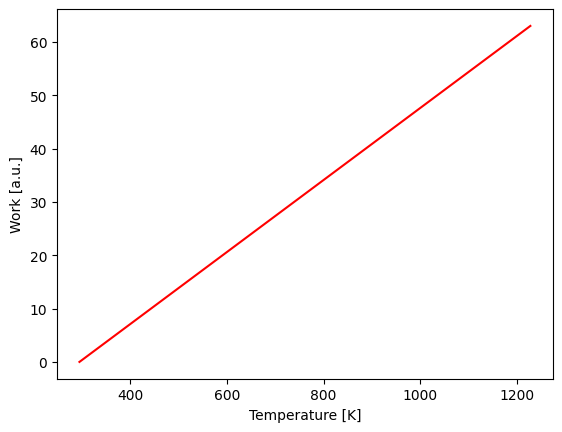

In [17]:
# VOORBEELDUITWERKING

particles = []
temperatures = np.zeros(1000, dtype=float)
works = np.zeros(1000, dtype=float)
# volumes = np.zeros(1000, dtype=float)
# pressures = np.zeros(1000, dtype=float)
# times = np.linspace(1, 100, 100)

pressure = 0.0
work = 0.0
box_length = BOX_SIZE_0         # zetten zuiger terug
v_piston = V_PISTON_0
create_particles(particles)     # resetten deeltjes 
for i in range(1000):
    take_time_step(particles)
    temperatures[i] = temperature(particles)
    works[i] = work

plt.figure()
plt.xlabel('Temperature [K]')
plt.ylabel('Work [a.u.]')

temperatures = np.asarray(temperatures) * 30 * 1.7E-27 * (1E-9 / 2.5E-12)**2 / 1.38E-23

plt.plot(temperatures, works, '-r')

plt.show()

Als laatste onderdeel van dit werkblad maken we een eenvoudige cyclus. We comprimeren het volume gedurende 1000 tijdstappen en keren daarna in 1000 gelijke tijdstappen terug naar het startvolume. 

```{exercise}
Herhaal voor deze simulatie de vorige plot. Gebruik een verschillende kleur voor de grafiek tijdens de compressie en de decompressie.
```

In [18]:
# RUIMTE VOOR UITWERKING

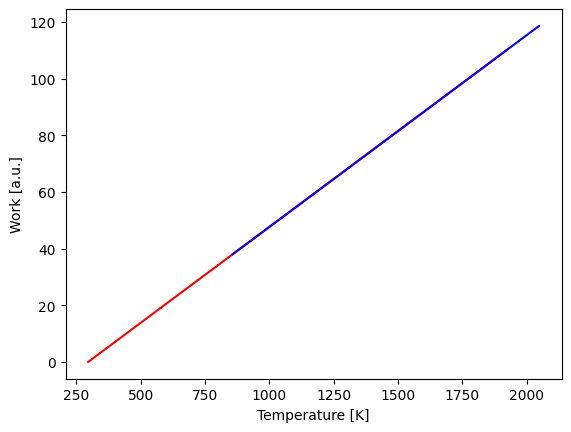

In [19]:
# VOORBEELDUITWERKING

particles = []
temperatures = np.zeros(200, dtype=float)
works = np.zeros(200, dtype=float)
# volumes = np.zeros(1000, dtype=float)
# pressures = np.zeros(1000, dtype=float)
# times = np.linspace(1, 100, 100)

pressure = 0.0
work = 0.0
box_length = BOX_SIZE_0         # zetten zuiger terug
v_piston = 10 * V_PISTON_0
create_particles(particles)     # resetten deeltjes 
for i in range(100):
    take_time_step(particles)
    temperatures[i] = temperature(particles)
    works[i] = work
v_piston = -10 * V_PISTON_0
for i in range(100,200):
    take_time_step(particles)
    temperatures[i] = temperature(particles)
    works[i] = work

plt.figure()
plt.xlabel('Temperature [K]')
plt.ylabel('Work [a.u.]')

temperatures = np.asarray(temperatures) * 30 * 1.7E-27 * (1E-9 / 2.5E-12)**2 / 1.38E-23

plt.plot(temperatures[0:99], works[0:99], '-r')
plt.plot(temperatures[100:199], works[100:199], '-b')

plt.show()

```{exercise}
Herhaal deze simulatie maar nu met een 5 keer zo hoge snelheid voor de zuiger in beide richtingen. Pas het aantal tijdstappen aan, zodat de zuiger in één 'slag' dezelfde afstand aflegt. 
```

In [20]:
# RUIMTE VOOR UITWERKING

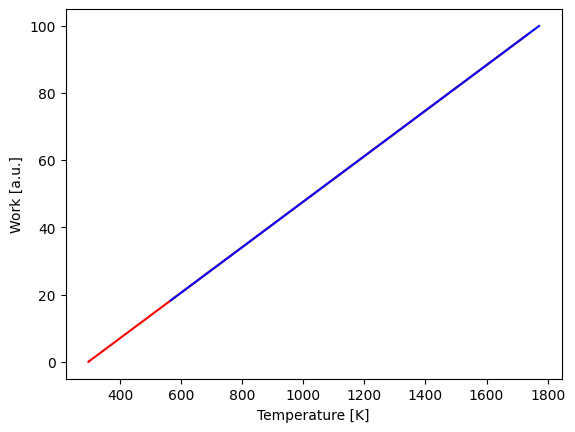

In [27]:
# VOORBEELDUITWERKING

particles = []
temperatures = np.zeros(400, dtype=float)
works = np.zeros(400, dtype=float)
# volumes = np.zeros(1000, dtype=float)
# pressures = np.zeros(1000, dtype=float)
# times = np.linspace(1, 100, 100)

pressure = 0.0
work = 0.0
box_length = BOX_SIZE_0         # zetten zuiger terug
v_piston = 5 * V_PISTON_0
create_particles(particles)     # resetten deeltjes 
for i in range(200):
    take_time_step(particles)
    temperatures[i] = temperature(particles)
    works[i] = work
v_piston = -5 * V_PISTON_0
for i in range(200, 400):
    take_time_step(particles)
    temperatures[i] = temperature(particles)
    works[i] = work

plt.figure()
plt.xlabel('Temperature [K]')
plt.ylabel('Work [a.u.]')

temperatures = np.asarray(temperatures) * 30 * 1.7E-27 * (1E-9 / 2.5E-12)**2 / 1.38E-23

plt.plot(temperatures[0:199], works[0:199], '-r')
plt.plot(temperatures[200:399], works[200:399], '-b')

plt.show()

In deze laatste simulatie zie je (bij een correcte code) dat nog altijd netjes wordt voldaan aan de eerste hoofdwet. Ondanks dat, zie je dat het systeem niet terugkeert in dezelfde toestand als in het begin. In het boek wordt dit omschreven in het deel over 'quasiequilibrium': Processen moeten voldoende traag plaatsvinden zodat er zich een evenwicht kan vormen binnen het gas. Als processen te snel plaatsvinden is er geen sprake van equilibrium en kan je de macroscopische thermodynamische formules niet langer gebruiken.

```{exercise}
Reken de snelheid van de zuiger bij de laatste twee processen om naar een snelheid in SI-eenheden. De kwaliteit van onze simulaties is onvoldoende gedetailleerd om echt uitspraken te kunnen doen over non-equilibrium processen. Maar het antwoord stelt toch gerust.
```

```{exercise}
Laat je werkboek aftekenen door een student.
```